# Install the needed library


In [1]:
pip install -r /kaggle/input/datasets/phmhuyphongp/cross-sectional-rank-vn-requirements/requirements-dev.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.8/275.8 kB 3.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 59.1 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 83.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 82.1 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 3.3 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following de

# Import library

In [2]:
import pandas as pd
import numpy as np
import os
import sys
project_root = os.path.abspath('/kaggle/input/datasets/phmhuyphongp/modules-vn')
if project_root not in sys.path:
    sys.path.append(project_root)

import src.models as md
import src.evaluation as ev
import src.features as ft
from config import candidate_features, BASE_MODEL_PARAMS

# Preprocessing Data

In [3]:
df = pd.read_parquet('/kaggle/input/datasets/phmhuyphongp/qualified-stocks-for-researching/market_data_filtered.parquet')

In [4]:
df['date'] = pd.to_datetime(df['date'])

excluded_dates = pd.to_datetime(['2018-01-23', '2018-01-24'])

df = df[~df['date'].isin(excluded_dates)].copy()

In [5]:
df = ft.build_features(df = df,min_stocks_per_date=0,adtv_limit = 2_500_000)
df.shape

/kaggle/input/datasets/phmhuyphongp/modules-vn/src/features.py:220: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  daily_ret = lagged_close.groupby(df["Symbol"]).pct_change()
/kaggle/input/datasets/phmhuyphongp/modules-vn/src/features.py:311: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  abs_ret = lagged_close.groupby(df["Symbol"]).pct_change().abs()
/kaggle/input/datasets/phmhuyphongp/modules-vn/src/features.py:320: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be 

Generating WorldQuant Alphas...


/kaggle/input/datasets/phmhuyphongp/modules-vn/src/alpha_mining.py:153: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ldf["daily_ret"] = ldf.groupby("Symbol")["close"].pct_change()
/kaggle/input/datasets/phmhuyphongp/modules-vn/src/alpha_mining.py:303: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ldf["ret"] = ldf.groupby("Symbol")["close"].pct_change()
/kaggle/input/datasets/phmhuyphongp/modules-vn/src/features.py:409: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will

(322535, 80)

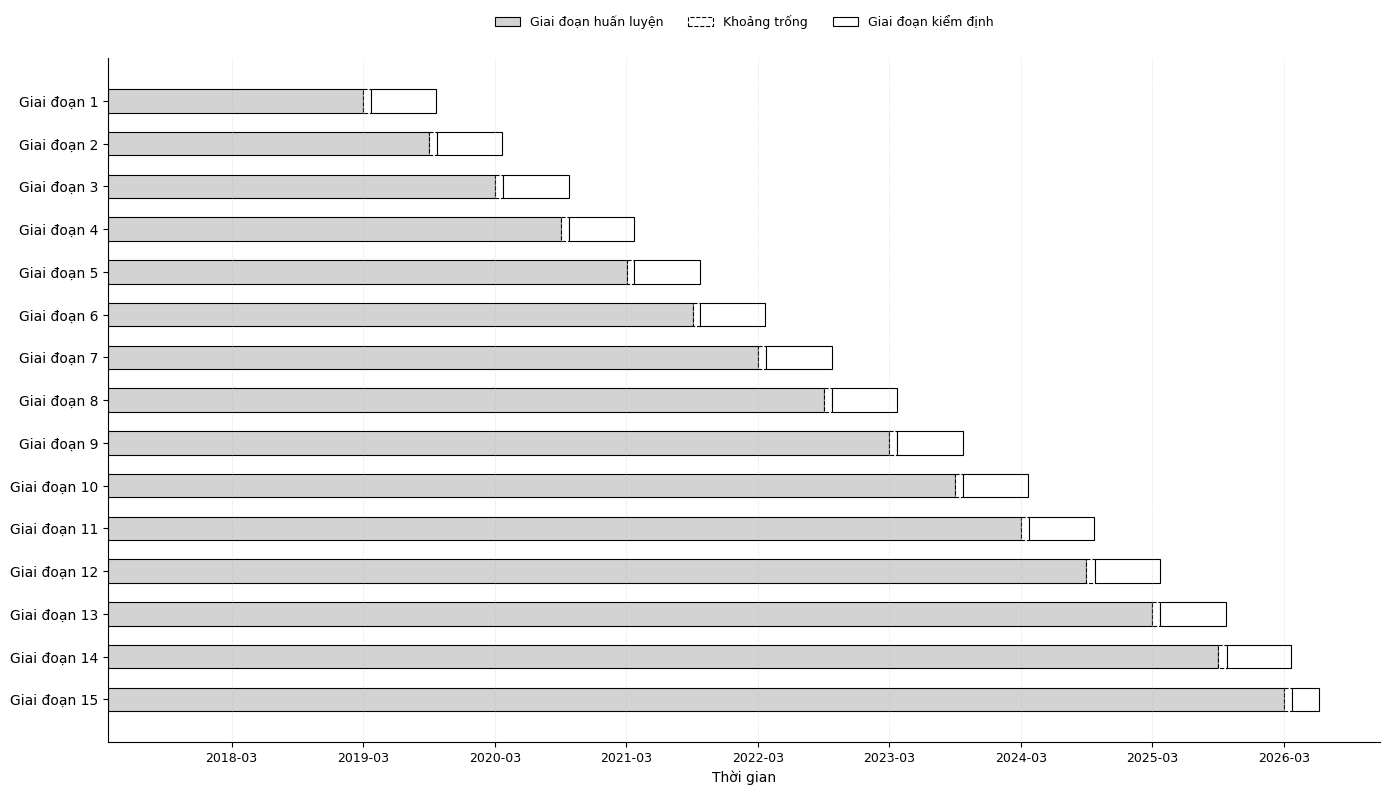

In [ ]:


BASIC_FEATURES = candidate_features

WF_PARAMS = dict(initial_train_months=24, test_months=6, gap_days=21)

In [ ]:
MODEL_PARAMS ={
    'device':             'cuda',
    'tree_method':        'hist',
    'objective':          'rank:ndcg',
    'random_state':       42,
    # Tree structure
    'n_estimators':       150,
    'max_depth':          3,
    'min_child_weight':   5,
    # Learning
    'learning_rate':      0.03,
    # Sampling
    'subsample':          0.7,
    'colsample_bytree':   0.6,
    # Regularization
    'reg_lambda':         5.0,
    'reg_alpha':          1,
    # Ranking
    'lambdarank_pair_method':         'topk',
    'lambdarank_num_pair_per_sample':  20,
    'n_jobs':          -1,
    'ndcg_exp_gain':False,

}

In [ ]:
df_predict_lstm,_ = md.walk_forward_cv(
    df=df,
    model='lstm_mse',
    model_params=MODEL_PARAMS,
    features=BASIC_FEATURES,
    icir_filter=False,
    corr_prune=True,
    **WF_PARAMS,
)

In [ ]:
df_predict_lstm.to_parquet('lstm.parquet')

In [ ]:
df_predict_ndcg,_ = md.walk_forward_cv(
    df=df,
    model_params=MODEL_PARAMS,
    features=BASIC_FEATURES,
    icir_filter=False,
    corr_prune=True,
    **WF_PARAMS,
)

In [ ]:
df_predict_ndcg.to_parquet('ndcg.parquet')

In [ ]:
df_predict_mse,_ = md.walk_forward_cv(
    df=df,
    model='xgboost_mse',
    model_params=MODEL_PARAMS,
    features=BASIC_FEATURES,
    icir_filter=False,
    corr_prune=True,
    **WF_PARAMS,
)

In [ ]:
df_predict_mse.to_parquet('mse.parquet')

In [ ]:

df_predict_linear,_ =  md.walk_forward_cv(
    df=df,
    model='linear',
    model_params=MODEL_PARAMS,
    features=BASIC_FEATURES,
    icir_filter=False,
    corr_prune=True,
    **WF_PARAMS,
)

In [ ]:
df_predict_linear.to_parquet('linear.parquet')